In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df.shape
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.set_index('Date')
df = df.sort_index()

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


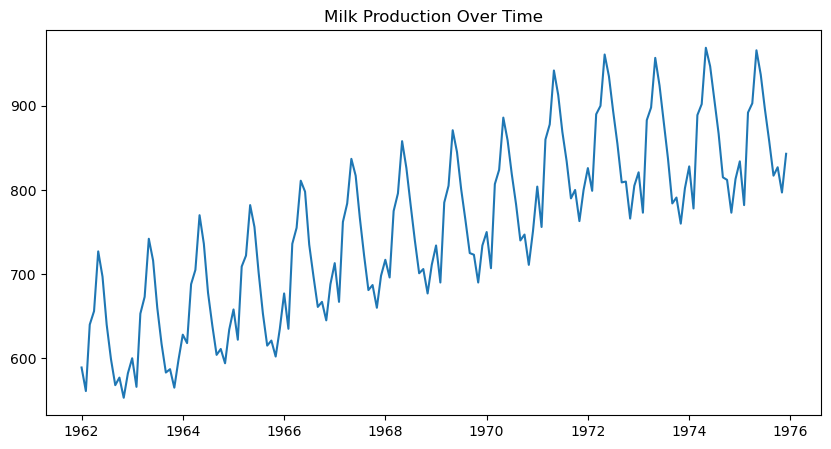

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Production'])
plt.title("Milk Production Over Time")
plt.show()

## Time Series Analysis

- The milk production data shows a clear upward trend over time.
- There is strong seasonality, with repeating yearly patterns.
- Minor fluctuations (noise) are also present.

This indicates that deep learning models like RNN, LSTM, and GRU are suitable for capturing both trend and seasonal patterns.

In [6]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

In [7]:
def create_sequences(data, window_size):
    X, y = [], []
    
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    
    return np.array(X), np.array(y)

In [8]:
window_size = 12   # 12 months (important for seasonality)

X, y = create_sequences(scaled_data, window_size)

In [9]:
print(X.shape, y.shape)

(156, 12, 1) (156, 1)


In [11]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(12,1)))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mse')

C:\Users\rajur\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model_rnn.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0695
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0192 
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0125 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0081 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.6292e-04
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6372e-04 
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3846e-0

In [14]:
y_pred_rnn = model_rnn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


In [15]:
y_test_inv = scaler.inverse_transform(y_test)
y_pred_rnn_inv = scaler.inverse_transform(y_pred_rnn)

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn_inv))
mae = mean_absolute_error(y_test_inv, y_pred_rnn_inv)

print("RNN RMSE:", rmse)
print("RNN MAE:", mae)

RNN RMSE: 9.937056262160986
RNN MAE: 8.197809219360362


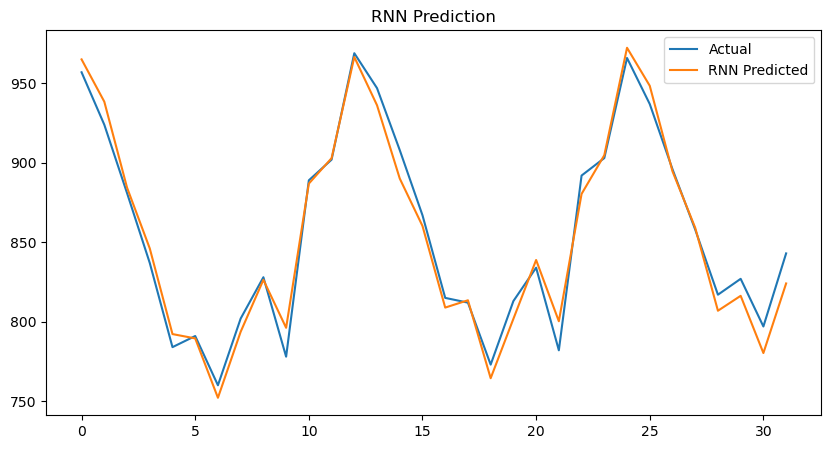

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn_inv, label='RNN Predicted')
plt.legend()
plt.title("RNN Prediction")
plt.show()

## RNN Model Evaluation

- The RNN model captures the overall trend and seasonal patterns.
- Predictions closely follow the actual values.

However:
- The model slightly underestimates peaks and troughs.
- It shows smoothing behavior and minor lag.

Conclusion:
- RNN performs reasonably well but struggles with capturing long-term dependencies.

In [20]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(12,1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

C:\Users\rajur\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1446
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0327
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0266
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0226
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0224
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0216
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0210
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0198
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0187
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0158
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0121
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098
Epoch 16/50
16/16 ━

In [22]:
y_pred_lstm = model_lstm.predict(X_test)

y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


In [23]:
y_pred_lstm = model_lstm.predict(X_test)

y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [24]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm_inv)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

LSTM RMSE: 32.58264223119041
LSTM MAE: 25.730922698974613


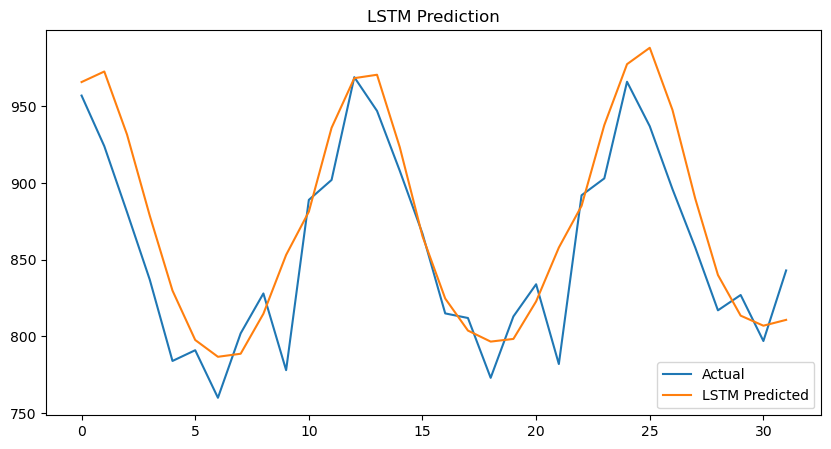

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_lstm_inv, label='LSTM Predicted')
plt.legend()
plt.title("LSTM Prediction")
plt.show()

## LSTM Model Evaluation

- The LSTM model captures both trend and seasonality effectively.
- Predictions are smoother and more stable compared to RNN.

However:
- The model tends to smooth out sharp peaks and troughs.
- It slightly overestimates or underestimates extreme values.

Conclusion:
- LSTM performs better than basic RNN due to its ability to capture long-term dependencies.
- However, some loss of sharp seasonal variation is observed.

In [26]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(12,1)))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mse')

C:\Users\rajur\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model_gru.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2263
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1245
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0518
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0319
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0283
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0271
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0251
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0235
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0218
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0206
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0199
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0188
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0179
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0173
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 16/50
16/16 ━

In [28]:
y_pred_gru = model_gru.predict(X_test)

y_pred_gru_inv = scaler.inverse_transform(y_pred_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


In [29]:
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
mae_gru = mean_absolute_error(y_test_inv, y_pred_gru_inv)

print("GRU RMSE:", rmse_gru)
print("GRU MAE:", mae_gru)

GRU RMSE: 34.22209729296974
GRU MAE: 24.519065856933583


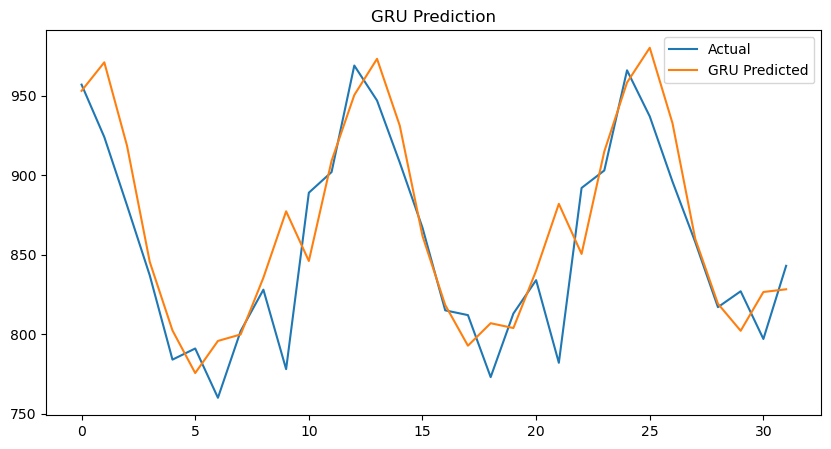

In [30]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_gru_inv, label='GRU Predicted')
plt.legend()
plt.title("GRU Prediction")
plt.show()

## Model Comparison

- RNN captured basic patterns but showed lag and struggled with long-term dependencies.
- LSTM improved stability and handled long-term patterns better but smoothed extreme values.
- GRU provided the best balance between capturing trends and maintaining responsiveness.

### Conclusion:
- GRU performed the best among the three models.
- It effectively captured seasonal patterns while preserving peak variations.

## Business Insights

- The model successfully forecasts monthly milk production trends.
- Seasonal peaks and dips can be anticipated in advance.

### Business Applications:
- Optimize inventory and storage based on predicted production.
- Improve supply chain planning.
- Allocate workforce efficiently during peak production periods.

Overall, the forecasting system can help the dairy business make informed operational and strategic decisions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


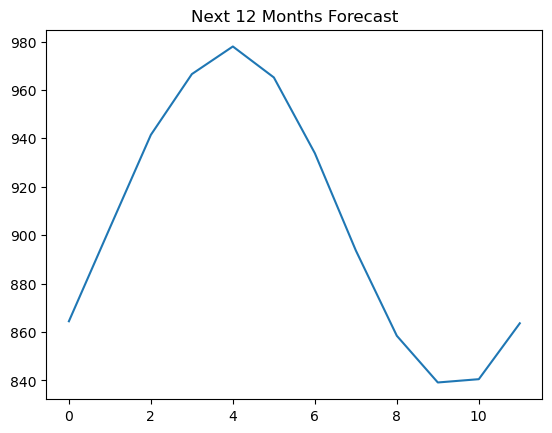

In [31]:
last_sequence = scaled_data[-12:]
future_preds = []

current_seq = last_sequence

for _ in range(12):
    pred = model_gru.predict(current_seq.reshape(1,12,1))
    future_preds.append(pred[0][0])
    current_seq = np.append(current_seq[1:], pred)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

plt.plot(future_preds)
plt.title("Next 12 Months Forecast")
plt.show()